Using device: cpu


100%|██████████| 5.00G/5.00G [02:27<00:00, 33.8MB/s]


Total classes in Food-101: 101
Subset size — train: 9000 images, test: 3000 images
Classes: ['pizza', 'sushi', 'hamburger', 'ramen', 'fried_rice', 'ice_cream', 'steak', 'caesar_salad', 'chicken_wings', 'french_fries', 'donuts', 'pad_thai']
Corrupted/unreadable images found in train subset: 0
Per-class image counts (train / test):
  pizza               train= 750   test= 250
  sushi               train= 750   test= 250
  hamburger           train= 750   test= 250
  ramen               train= 750   test= 250
  fried_rice          train= 750   test= 250
  ice_cream           train= 750   test= 250
  steak               train= 750   test= 250
  caesar_salad        train= 750   test= 250
  chicken_wings       train= 750   test= 250
  french_fries        train= 750   test= 250
  donuts              train= 750   test= 250
  pad_thai            train= 750   test= 250


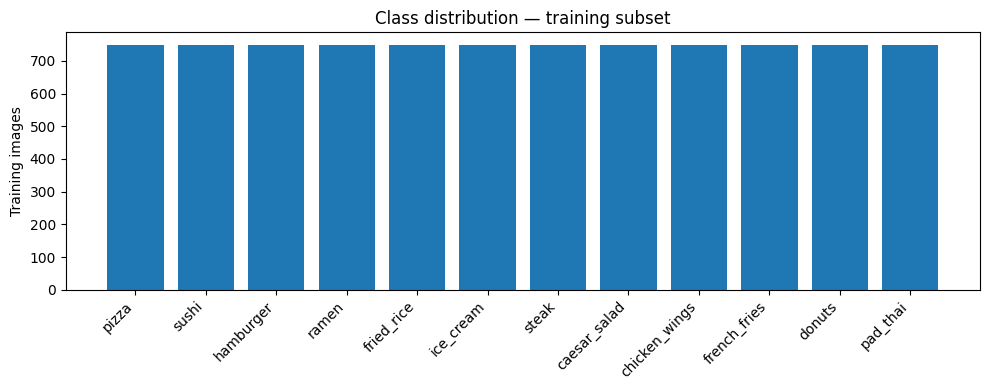

Final split — train: 7650, val: 1350, test: 3000
Batches — train: 240, val: 43, test: 94
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 63.7MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=12, bias=True)
)
Phase 1 — training classifier head only (backbone frozen)
Epoch 1/5 — train_loss 1.382 acc 0.644 | val_loss 0.945 acc 0.746
Epoch 2/5 — train_loss 0.900 acc 0.742 | val_loss 0.785 acc 0.774
Epoch 3/5 — train_loss 0.809 acc 0.760 | val_loss 0.725 acc 0.784


In [ ]:
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B0_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
from collections import Counter
from google.colab import files

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SELECTED_CLASSES = [
    "pizza", "sushi", "hamburger", "ramen", "fried_rice", "ice_cream",
    "steak", "caesar_salad", "chicken_wings", "french_fries", "donuts", "pad_thai",
]
NUM_CLASSES = len(SELECTED_CLASSES)
DATA_ROOT = "./food101_data"

print("Downloading Food-101 (~5GB, one-time, takes a few minutes)...")
full_train_raw = datasets.Food101(root=DATA_ROOT, split="train", download=True)
full_test_raw = datasets.Food101(root=DATA_ROOT, split="test", download=True)
print("Total classes in Food-101:", len(full_train_raw.classes))

selected_idx_set = {full_train_raw.class_to_idx[c] for c in SELECTED_CLASSES}


def subset_indices(base_dataset):
    return [i for i, label in enumerate(base_dataset._labels) if label in selected_idx_set]


train_indices = subset_indices(full_train_raw)
test_indices = subset_indices(full_test_raw)

print(f"Subset size — train: {len(train_indices)} images, test: {len(test_indices)} images")
print(f"Classes: {SELECTED_CLASSES}")


def verify_images(base_dataset, indices):
    bad = []
    for i in indices:
        path = base_dataset._image_files[i]
        try:
            with Image.open(path) as img:
                img.convert("RGB")
        except Exception as e:
            bad.append((i, path, str(e)))
    return bad


bad_train = verify_images(full_train_raw, train_indices)
print(f"Corrupted/unreadable images found in train subset: {len(bad_train)}")
if bad_train:
    bad_idx = {b[0] for b in bad_train}
    train_indices = [i for i in train_indices if i not in bad_idx]

train_label_counts = Counter(full_train_raw._labels[i] for i in train_indices)
test_label_counts = Counter(full_test_raw._labels[i] for i in test_indices)

print("Per-class image counts (train / test):")
for c in SELECTED_CLASSES:
    idx = full_train_raw.class_to_idx[c]
    print(f"  {c:18s}  train={train_label_counts[idx]:4d}   test={test_label_counts[idx]:4d}")

plt.figure(figsize=(10, 4))
plt.bar(SELECTED_CLASSES, [train_label_counts[full_train_raw.class_to_idx[c]] for c in SELECTED_CLASSES])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Training images")
plt.title("Class distribution — training subset")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

random.shuffle(train_indices)
val_split = int(0.15 * len(train_indices))
val_indices = train_indices[:val_split]
train_indices_final = train_indices[val_split:]
print(f"Final split — train: {len(train_indices_final)}, val: {len(val_indices)}, test: {len(test_indices)}")

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class_to_new_idx = {full_train_raw.class_to_idx[c]: i for i, c in enumerate(SELECTED_CLASSES)}


class FoodSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        img, old_label = self.base[real_idx]
        img = img.convert("RGB")
        img = self.transform(img)
        new_label = class_to_new_idx[old_label]
        return img, new_label


train_ds = FoodSubset(full_train_raw, train_indices_final, train_transform)
val_ds = FoodSubset(full_train_raw, val_indices, eval_transform)
test_ds = FoodSubset(full_test_raw, test_indices, eval_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")


def build_model(num_classes, pretrained=True):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES).to(device)

# Phase 1: freeze the feature extractor, train only the new head
for param in model.features.parameters():
    param.requires_grad = False

print(model.classifier)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(is_train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

PHASE1_EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Phase 1 — training classifier head only (backbone frozen)")
for epoch in range(PHASE1_EPOCHS):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{PHASE1_EPOCHS} — train_loss {tr_loss:.3f} acc {tr_acc:.3f} | val_loss {val_loss:.3f} acc {val_acc:.3f}")

# Phase 2: unfreeze the last few blocks and fine-tune at a lower learning rate
for param in model.features[-3:].parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

PHASE2_EPOCHS = 10
print("Phase 2 — fine-tuning last blocks + head")
for epoch in range(PHASE2_EPOCHS):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{PHASE2_EPOCHS} — train_loss {tr_loss:.3f} acc {tr_acc:.3f} | val_loss {val_loss:.3f} acc {val_acc:.3f}")

epochs_range = range(1, len(history["train_acc"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].axvline(PHASE1_EPOCHS, color="gray", linestyle="--", label="phase 2 starts")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].axvline(PHASE1_EPOCHS, color="gray", linestyle="--", label="phase 2 starts")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Test accuracy: {test_acc*100:.2f}%")
print(classification_report(all_labels, all_preds, target_names=SELECTED_CLASSES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

torch.save(model.state_dict(), "food_classifier.pth")
with open("class_names.json", "w") as f:
    json.dump(SELECTED_CLASSES, f, indent=2)

print("Saved food_classifier.pth and class_names.json")
print(f"\nFinal test accuracy: {test_acc*100:.2f}% ")

files.download("food_classifier.pth")
files.download("class_names.json")